# Calibration of refractive index

Here, we use height data from Tomocube and Holomonitor to calibrate the refractive index distribution for Tomocube. 
The calibration relies on the assumption that both microscopes measure the same quantity, 
$\int dz \,\Delta \bar{n}(\rho)$, under different assumptions.

- Holomonitor assumes a constant $\bar{n}(\rho) = 1.38-1.34=0.04$, such that $\int dz \,\Delta \bar{n}(\rho) = 0.04\,\bar{h}$
- Tomocube does not assume anything about the density dependence of the RI contrast, but the measurements are not calibrated.

In [ ]:
import sys
import json
import numpy as np
import scipy as sc
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.optimize import least_squares

sys.path.append("scripts/utils/")
from file_operations import *
from SegmentedCells  import SegmentedCells
from Microscopes     import Holomonitor, Tomocube

In [11]:
n_shift = 0.002    # Correction shift for Tomocube RI field
_2DQPI = Holomonitor()
_3DQPI = Tomocube()

In [62]:
data_path = "../../../../hdd_data/silja/Monolayers/"

datasets_2D = [
    #"MDCK_20240301_B1-4",
    "MDCK_20240319_A1-13",
    # "MDCK_20240319_A1-18",
    "MDCK_20240319_B1-11",
    # "MDCK_20240516_A2-1", 
    # "MDCK_20240516_A2-7",
    # "MDCK_20240516_B1-13",
    # "MDCK_20240516_B1-22"
]

datasets_3D = [
    # "MDCK_20250904_B1-1",
    # "MDCK_20250210_A2-1"
]

# Colormaps for plots
cmap_2D = mpl.colormaps['Blues']  (np.linspace(0.2, 0.9, len(datasets_2D)))
cmap_3D = mpl.colormaps['Greens'] (np.linspace(0.5, 0.7, len(datasets_3D)))

In [63]:
hmean_2D     = []
densities_2D = []

for dataset in datasets_2D:

    # load data
    config = json.load(open(f"configs/{dataset}.json"))
    stack  = load_stack(f"{data_path}height_fields/{dataset}/", config, data_type="cells")
    cells  = SegmentationData(f"{data_path}cell_features/{dataset}_cells.p")

    # Compute mean height of monolayer
    hmean_tmp = np.array([np.mean(frame[frame > 0]) for frame in stack])
    if config["boundary"] == "open":
        hmean_tmp += _2DQPI.hshift

    hmean_2D.append( hmean_tmp )
    densities_2D.append(cells.density)


State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/MDCK_20240319_A1-13_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/MDCK_20240319_B1-11_cells.p.


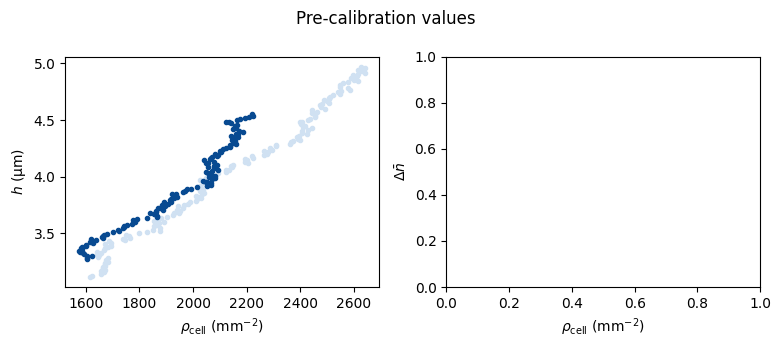

In [64]:
fig, ax = plt.subplots(1,2, figsize=(8,3.5))
fig.suptitle("Pre-calibration values")
ax[0].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$h$ (µm)");
ax[1].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$\Delta \bar{n}$");

for h, rho, c in zip(hmean_2D,
                     densities_2D,
                     cmap_2D):
    ax[0].plot(rho, h, '.', c=c)

fig.tight_layout()

In [ ]:
hmean_3D     = []
nmean_3D     = []
densities_3D = []

for dataset in datasets_3D:

    # load data
    config  = json.load(open(f"configs/{dataset}.json"))
    hstack  = load_stack(f"{data_path}height_fields/{dataset}/", config, param="height", data_type="cells")
    nstack  = load_stack(f"{data_path}height_fields/{dataset}/", config, param="ri",     data_type="cells")
    cells   = SegmentationData(f"{data_path}cell_features/{dataset}_cells.p")

    # Compute mean height of monolayer
    hmean_tmp = np.array([np.mean(h[h > 0]) for h in hstack])
    nmean_tmp = np.array([np.mean(n[h > 0]) for n,h in zip(nstack, hstack)])

    hmean_3D.append( hmean_tmp )
    nmean_3D.append( nmean_tmp )
    densities_3D.append(cells.density)


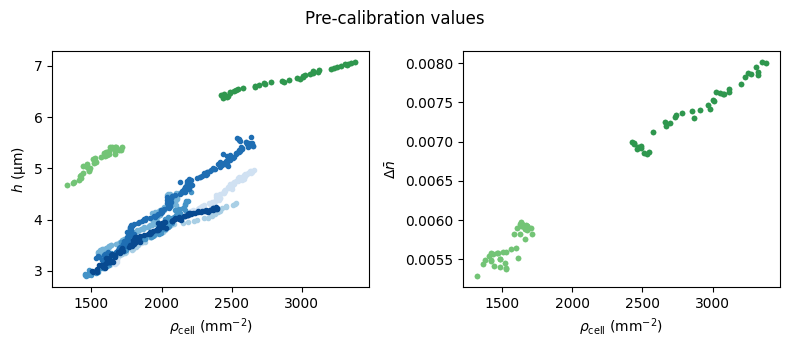

In [ ]:
# nmean_3D[0] += ndelta

fig, ax = plt.subplots(1,2, figsize=(8,3.5))
fig.suptitle("Pre-calibration values")
ax[0].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$h$ (µm)");
ax[1].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$\Delta \bar{n}$");

for h, rho, c in zip(hmean_2D,
                     densities_2D,
                     cmap_2D):
    ax[0].plot(rho, h, '.', c=c)


for h, n, rho, c in zip(hmean_3D,
                        nmean_3D,
                        densities_3D,
                        cmap_3D):
    ax[0].plot(rho, h, '.', c=c)
    ax[1].plot(rho, n - _3DQPI.n0, '.', c=c)

fig.tight_layout() 
fig

## Bin by density

In [273]:
density_bins = np.arange(1300, 3400, 100)
density      = (density_bins[1:] + density_bins[:-1]) / 2

In [355]:
hs_arr = []
ns_arr = []

sighs_arr = []
sighn_arr = []

# Bin data by density
i = 0
for rhos, hs in zip([densities_2D, densities_3D],
                    [hmean_2D,     hmean_3D]):
    
    h_arr = []
    n_arr = []

    sigh_arr = []
    sign_arr = []

    j = 0
    for rho, h in zip(rhos, hs):
        bin_idx = np.digitize(rho, density_bins) - 1

        # Only keep x values that fall inside bins
        mask = (bin_idx >= 0) & (bin_idx < len(density_bins) - 1)

        bin_idx = bin_idx[mask]
        h_tmp   = h[mask] 

        # Aggregate y per bin, e.g. sum and mean
        hbinned   = np.bincount(bin_idx, weights=h_tmp, minlength=len(density_bins)-1)
        count     = np.bincount(bin_idx, minlength=len(density_bins)-1)

        hbinned[count > 0] = hbinned[count > 0] / count[count > 0]
        h_arr.append(np.ma.array(hbinned, mask=hbinned==0))
        
        if i == 1:
            n_tmp   = nmean_3D[j][mask]
            nbinned = np.bincount(bin_idx, weights=n_tmp, minlength=len(density_bins)-1)
            nbinned[count > 0] = nbinned[count > 0] / count[count > 0]
            n_arr.append(np.ma.array(nbinned, mask=nbinned==0))

        j += 1

    hs_arr.append(h_arr)
    ns_arr.append(n_arr)

    i += 1

hbinned_2D  = hs_arr[0]
hbinned_3D  = hs_arr[1]
nbinned_3D  = ns_arr[1]

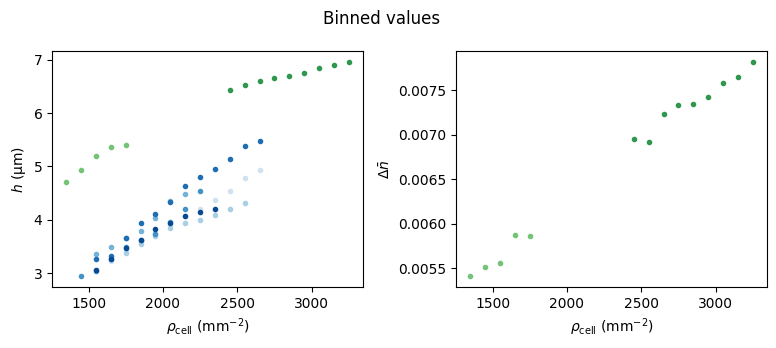

In [356]:
fig, ax = plt.subplots(1,2, figsize=(8,3.5))
fig.suptitle("Binned values")
ax[0].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$h$ (µm)");
ax[1].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$\Delta \bar{n}$");

for h, c in zip(hbinned_2D,
                cmap_2D):
    ax[0].plot(density,        h, '.', c=c)
    # ax[1].plot(density, f_2D * h, '.', c=c)

for h, n, c in zip(hbinned_3D,
                   nbinned_3D,
                   cmap_3D):
    ax[0].plot(density, h, '.', c=c)
    ax[1].plot(density, n - n0_3D, '.', c=c)

fig.tight_layout()

## Fit

In [375]:
h2D = np.ma.concatenate(hbinned_2D)
h3D = np.ma.concatenate(hbinned_3D)

rho_2D = np.tile(density, len(hbinned_2D))[~h2D.mask]
rho_3D = np.tile(density, len(hbinned_3D))[~h3D.mask]

h2D = h2D.compressed()
h3D = h3D.compressed()

w2D = 1
w3D = 0.5

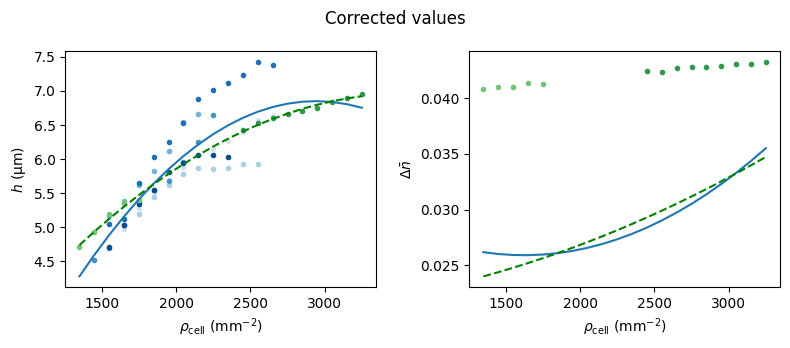

In [376]:
def poly2(p, x):
    return p[0] + p[1] * x + p[2] * x**2

def residuals(param):
    a     = param[0:3]
    theta = param[3:6]

    # Constraints: h_2D = Delta n * h_3D / f_2D
    h2D_pred = (1 / f_2D) * poly2(a, rho_2D) * poly2(theta, rho_2D) 
    h3D_pred = poly2(theta, rho_3D)

    r2D = (h2D - h2D_pred) * w2D
    r3D = (h3D - h3D_pred) * w3D

    return np.concatenate([r2D, r3D])

# a0: evaluate theta0 at rho_2D, form ratio, fit a polynomial to it.
h3D_at_2D = poly2(theta0, rho_2D)

valid = np.abs(h3D_at_2D) > 1e-12
if valid.sum() >= 3:
    ratio = 0.04 * h2D[valid] / h3D_at_2D[valid]
    a0 = np.polyfit(rho_2D[valid], ratio, 2)[::-1]
else:
    a0 = np.array([1.0, 0.0, 0.0])

p0 = np.concatenate([a0, theta0])

result = least_squares(residuals, p0, method='lm')
a     = result.x[0:3:]
theta = result.x[3:6]

ax[0].plot(density, poly2(theta, density), '--', c="green")
ax[1].plot(density, poly2(a, density),     '--', c="green")
fig

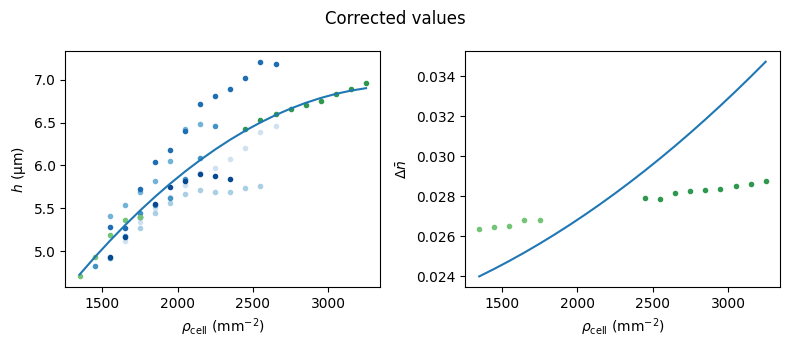

In [377]:
fig, ax = plt.subplots(1,2, figsize=(8,3.5))
fig.suptitle("Corrected values")
ax[0].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$h$ (µm)");
ax[1].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$\Delta \bar{n}$");

for h, c in zip(hbinned_2D,
                cmap_2D):
    ax[0].plot(density, f_2D * h / poly2(a, density), '.', c=c)
    #ax[1].plot(density, f_2D * h, '.', c=c)

for h, n, c in zip(hbinned_3D,
                   nbinned_3D,
                   cmap_3D):
    ax[0].plot(density, h, '.', c=c)
    ax[1].plot(density, a[0] + n - n0_3D, '.', c=c)


# final height fit
h_from_2D = 0.04 * h2D / poly2(a, rho_2D)

rho_combined = np.concatenate([rho_2D, rho_3D])
h_combined   = np.concatenate([h_from_2D, h3D])
w_combined   = np.concatenate([w2D * np.ones_like(rho_2D), w3D*np.ones_like(rho_3D)])

# weighted polyfit
beta = np.polyfit(rho_combined, h_combined, 2, w=w_combined)[::-1]

ax[0].plot(density, poly2(beta, density))
ax[1].plot(density, poly2(a, density))

fig.tight_layout()